In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("--- Environment Check ---")
print(f" PyTorch version : {torch.__version__}")
print(f" CUDA available  : {torch.cuda.is_available()}")
print(f" Using device    : {device}")
print("-------------------------")

--- Environment Check ---
 PyTorch version : 2.1.0+cpu
 CUDA available  : False
 Using device    : cpu
-------------------------


In [4]:
import os
import shutil
import random

BASE_DIR = "../datasets" 

CLASSES = ["Drought", "Healthy", "Pest"]

VAL_SPLIT = 0.2 

print(" Creating train and val folders...")
for split in ["train", "val"]:
    for cls in CLASSES:
        os.makedirs(os.path.join(BASE_DIR, split, cls), exist_ok=True)

print(" Shuffling and moving images. Please wait...")
for cls in CLASSES:
    src_folder = os.path.join(BASE_DIR, cls)
    
    if not os.path.exists(src_folder):
        print(f"   Skipping {cls}: Folder not found at {src_folder}")
        continue
        
    images = [f for f in os.listdir(src_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    random.seed(42) 
    random.shuffle(images)
    
    split_idx = int(len(images) * (1 - VAL_SPLIT))
    train_images = images[:split_idx]
    val_images = images[split_idx:]
    
    print(f"   {cls}: Moving {len(train_images)} to train, {len(val_images)} to val")
    
    for img in train_images:
        shutil.move(os.path.join(src_folder, img), os.path.join(BASE_DIR, "train", cls, img))
        
    for img in val_images:
        shutil.move(os.path.join(src_folder, img), os.path.join(BASE_DIR, "val", cls, img))
        
print(" All done! Your dataset is perfectly organized.")

 Creating train and val folders...
 Shuffling and moving images. Please wait...
   Drought: Moving 640 to train, 160 to val
   Healthy: Moving 640 to train, 160 to val
   Pest: Moving 640 to train, 160 to val
 All done! Your dataset is perfectly organized.


In [ ]:
TRAIN_DIR      = "../datasets/train"
VAL_DIR        = "../datasets/val"
               
IMG_SIZE       = 224
BATCH_SIZE     = 32
EXTRA_EPOCHS   = 20
CONF_THRESHOLD = 0.80

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")

✅ Using device: cpu


In [ ]:

# CELL 4 — Transforms & Datasets
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=45),
    transforms.ColorJitter(brightness=0.3,
                           contrast=0.3,
                           saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=VAL_DIR,   transform=val_test_transforms)

CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Classes       : {CLASS_NAMES}")
print(f"✅ Train samples : {len(train_dataset)}")
print(f"✅ Val samples   : {len(val_dataset)}")

✅ Classes       : ['ClassA-Drought', 'ClassB-PestInfestation', 'ClassC-Healthy']
✅ Train samples : 1773
✅ Val samples   : 1773


In [ ]:

# CELL 5 — Load Saved Model and Apply All Fixes
import os

# Build model architecture
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

# Load saved weights if available
if os.path.exists(OLD_MODEL_PATH):
    checkpoint = torch.load(OLD_MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"✅ Loaded saved model from: {OLD_MODEL_PATH}")
else:
    print(f"⚠️  No saved model found at {OLD_MODEL_PATH}")
    print("   Loading fresh ImageNet weights instead")
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model = model.to(device)

# FIX 1: Unfreeze layer3, layer4, fc 
for name, param in model.named_parameters():
    if "layer3" in name or "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False
print("✅ Fix 1: Unfroze layer3, layer4, fc")

# FIX 2: Class weights
class_weights = torch.tensor([1.0, 2.0, 1.5]).to(device)
criterion     = nn.CrossEntropyLoss(weight=class_weights)
print("✅ Fix 2: Class weights applied (Pest=2.0x, Healthy=1.5x)")

# FIX 3: Layered optimizer 
optimizer = optim.Adam([
    {"params": model.layer3.parameters(), "lr": 1e-5},
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(),     "lr": 1e-3},
])
print("✅ Fix 3: Layered optimizer ready")
print("\n🚀 All fixes applied — ready to train!")

✅ Loaded saved model from: C:\Users\ACER\Downloads\resnet18_rice_v2.pth
✅ Fix 1: Unfroze layer3, layer4, fc
✅ Fix 2: Class weights applied (Pest=2.0x, Healthy=1.5x)
✅ Fix 3: Layered optimizer ready

🚀 All fixes applied — ready to train!


In [ ]:

# CELL 6 — Training Loop

best_val_acc = 0.9966   # to protect model from being overwritten

for epoch in range(EXTRA_EPOCHS):
    print(f"Epoch {epoch+1}/{EXTRA_EPOCHS}")
    print("-" * 30)
    start_time = time.time()

    #TRAIN
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train   = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * inputs.size(0)
        _, predicted   = torch.max(outputs, 1)
        total_train   += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_dataset)
    epoch_train_acc  = correct_train / total_train

    # VALIDATE
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val   = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val   += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc  = correct_val / total_val
    elapsed        = time.time() - start_time

    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f}")
    print(f"Time: {elapsed:.2f}s")

    #Auto save best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save({
            "model_state_dict"    : model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "class_names"         : CLASS_NAMES,
            "num_classes"         : NUM_CLASSES,
            "epoch"               : epoch + 1,
        }, NEW_MODEL_PATH)
        print(f"  ⭐ New best saved! Val Acc: {best_val_acc:.4f}")
    print()

print("✅ Training complete!")

Epoch 1/10
------------------------------
Train Loss: 0.1867 | Train Acc: 0.9425
Val Loss:   0.1080 | Val Acc:   0.9729
Time: 878.76s
  ⭐ New best saved! Val Acc: 0.9729

Epoch 2/10
------------------------------
Train Loss: 0.1100 | Train Acc: 0.9679
Val Loss:   0.0514 | Val Acc:   0.9836
Time: 867.96s
  ⭐ New best saved! Val Acc: 0.9836

Epoch 3/10
------------------------------
Train Loss: 0.0722 | Train Acc: 0.9803
Val Loss:   0.0534 | Val Acc:   0.9797
Time: 835.36s

Epoch 4/10
------------------------------
Train Loss: 0.0694 | Train Acc: 0.9780
Val Loss:   0.0291 | Val Acc:   0.9921
Time: 818.82s
  ⭐ New best saved! Val Acc: 0.9921

Epoch 5/10
------------------------------
Train Loss: 0.0442 | Train Acc: 0.9904
Val Loss:   0.0578 | Val Acc:   0.9757
Time: 766.32s

Epoch 6/10
------------------------------
Train Loss: 0.0283 | Train Acc: 0.9921
Val Loss:   0.0268 | Val Acc:   0.9898
Time: 798.67s

Epoch 7/10
------------------------------
Train Loss: 0.0317 | Train Acc: 0.9910
V

✅ Accuracy: 99.66%

                        precision    recall  f1-score   support

        ClassA-Drought       1.00      1.00      1.00       773
ClassB-PestInfestation       0.99      0.99      0.99       500
        ClassC-Healthy       0.99      0.99      0.99       500

              accuracy                           1.00      1773
             macro avg       1.00      1.00      1.00      1773
          weighted avg       1.00      1.00      1.00      1773



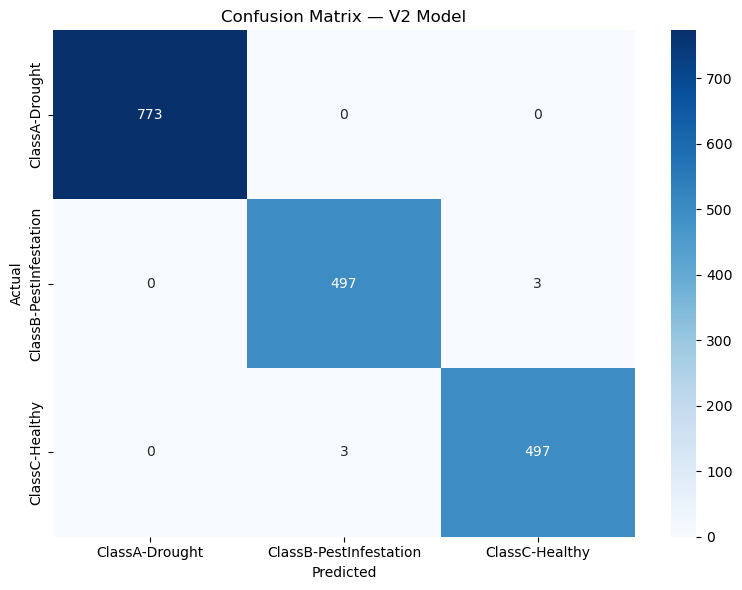


📊 Healthy vs Pest confusion:
   Healthy → wrongly Pest : 3  (target: <30)
   Pest → wrongly Healthy : 3  (target: <15)


In [ ]:

# CELL 7 — Evaluation + Confusion Matrix
all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs        = model(inputs)
        _, predicted   = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"✅ Accuracy: {test_acc*100:.2f}%\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix — V2 Model")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("\n📊 Healthy vs Pest confusion:")
print(f"   Healthy → wrongly Pest : {cm[2][1]}  (target: <30)")
print(f"   Pest → wrongly Healthy : {cm[1][2]}  (target: <15)")

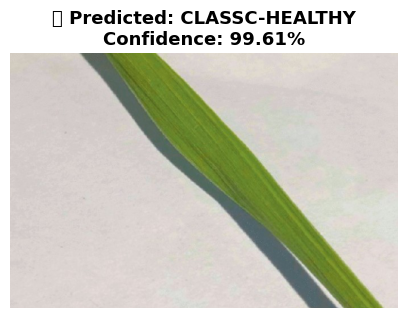


📊 All Probabilities:
  ClassA-Drought             0.02%  
  ClassB-PestInfestation     0.38%  
  ClassC-Healthy            99.61%  █████████████████████████████ ← top


('ClassC-Healthy', 0.9960669875144958)

In [16]:
def predict_with_threshold(image_path, model, class_names, device,
                            threshold=CONF_THRESHOLD):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    image      = Image.open(image_path).convert("RGB")
    tensor     = transform(image).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        outputs    = model(tensor)
        probs      = torch.softmax(outputs, dim=1)[0]
        confidence, predicted = torch.max(probs, 0)
    predicted_class = class_names[predicted.item()]
    conf_value      = confidence.item()
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    if conf_value < threshold:
        plt.title(
            f"⚠️ UNCERTAIN\nPossible: {predicted_class.upper()}\n"
            f"Confidence: {conf_value*100:.2f}% (below {threshold*100:.0f}%)\n"
            f"→ Recommend human review",
            fontsize=10, color="red", fontweight="bold"
        )
    else:
        plt.title(
            f"✅ Predicted: {predicted_class.upper()}\n"
            f"Confidence: {conf_value*100:.2f}%",
            fontsize=13, fontweight="bold"
        )
    plt.show()
    print("\n📊 All Probabilities:")
    for i, cls in enumerate(class_names):
        bar   = "█" * int(probs[i].item() * 30)
        alert = " ← top" if i == predicted.item() else ""
        print(f"  {cls:<25} {probs[i].item()*100:5.2f}%  {bar}{alert}")
    if conf_value < threshold:
        print(f"\n⚠️  Below {threshold*100:.0f}% threshold — recommend manual inspection")
    return predicted_class, conf_value

predict_with_threshold(IMAGE_PATH, model, CLASS_NAMES, device)

In [ ]:

# CELL 9 — Grad-CAM Heatmap
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def show_gradcam(image_path, model, class_names, device):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    image     = Image.open(image_path).convert("RGB")
    tensor    = transform(image).unsqueeze(0).to(device)
    rgb_image = np.array(image.resize((224, 224))) / 255.0
    model.eval()
    with torch.no_grad():
        outputs    = model(tensor)
        probs      = torch.softmax(outputs, dim=1)[0]
        confidence, predicted = torch.max(probs, 0)
    predicted_class = class_names[predicted.item()]
    target_layers = [model.layer4[-1]]
    cam           = GradCAM(model=model, target_layers=target_layers)
    targets       = [ClassifierOutputTarget(predicted.item())]
    grayscale_cam = cam(input_tensor=tensor, targets=targets)[0]
    visualization = show_cam_on_image(
        rgb_image.astype(np.float32), grayscale_cam, use_rgb=True
    )
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image.resize((224, 224)))
    axes[0].set_title("Original Image", fontsize=12)
    axes[0].axis("off")
    axes[1].imshow(grayscale_cam, cmap="jet")
    axes[1].set_title("Grad-CAM Heatmap", fontsize=12)
    axes[1].axis("off")
    axes[2].imshow(visualization)
    axes[2].set_title(
        f"Overlay\nPredicted: {predicted_class.upper()}\n"
        f"Confidence: {confidence.item()*100:.2f}%", fontsize=12
    )
    axes[2].axis("off")
    plt.suptitle("Grad-CAM — What the model focuses on",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print("\n📊 All Probabilities:")
    for i, cls in enumerate(class_names):
        bar = "█" * int(probs[i].item() * 30)
        print(f"  {cls:<25} {probs[i].item()*100:5.2f}%  {bar}")

show_gradcam(IMAGE_PATH, model, CLASS_NAMES, device)

NameError: name 'IMAGE_PATH' is not defined